In [2]:
from pathlib import Path
import sys

sys.path.append(str(Path().resolve().parent))


                           

                                                            
                                            

BASE_DIR = Path().resolve()
PROJECT_ROOT = BASE_DIR.parent   #to go un up the the root
DATA_DIR = PROJECT_ROOT / "data"

# Root directory of dataset
root = Path(DATA_DIR)


import numpy as np
import matplotlib.pyplot as plt 
from scipy.signal import find_peaks
import pandas as pd

In [3]:


def build_df(root):

    label_map = {
        1: "correct",
        2: "fast",
        3: "low_amplitude"
    }

    dfs = []   # store all partial dataframes

    for subject_dir in root.glob("s*"):
        for exercise_dir in subject_dir.glob("e*"):
            for unit_dir in exercise_dir.glob("u*"):

                file_path = unit_dir / "test.txt"

                df = pd.read_csv(file_path, sep=";")

                df["subject"] = subject_dir.name
                df["exercise"] = exercise_dir.name
                df["unit"] = unit_dir.name

                

                label_map = {
                    0: "correct",
                    1: "fast",
                    2: "low_amplitude"
                }

                segment_length = len(df) // 30

                df["execution_type"] = None

                for i in range(30):
                    start = i * segment_length
                    end = (i + 1) * segment_length

                    label_group = i // 10
                    label = label_map[label_group]

                    df.loc[start:end, "execution_type"] = label

                dfs.append(df)   # collect dataframe

    final_df = pd.concat(dfs, ignore_index=True)

    return final_df

In [4]:
df=build_df(root)


In [5]:
df[(df['subject']=='s1') & (df['exercise']=='e1') ]

,time index,acc_x,acc_y,acc_z,gyr_x,gyr_y,gyr_z,mag_x,mag_y,mag_z,subject,exercise,unit,execution_type
0,1,-9.685645,-1.645149,0.505022,-0.020696,0.009202,-0.008566,0.589728,0.453403,-0.075234,s1,e1,u1,correct
1,2,-9.648184,-1.645353,0.513125,-0.008165,-0.001407,-0.003256,0.587024,0.453644,-0.075593,s1,e1,u1,correct
2,3,-9.700570,-1.615223,0.512321,-0.004447,0.011059,-0.008589,0.589691,0.454598,-0.075525,s1,e1,u1,correct
3,4,-9.685627,-1.630183,0.497591,-0.026110,0.009183,-0.008554,0.589240,0.452864,-0.074705,s1,e1,u1,correct
4,5,-9.655697,-1.630194,0.460742,-0.008109,0.001231,-0.005950,0.589647,0.452882,-0.076429,s1,e1,u1,correct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29740,5945,-4.223868,-7.541800,-4.607269,-0.016858,-0.001904,-0.011902,0.003246,0.725318,0.231512,s1,e1,u5,None
29741,5946,-4.253123,-7.531929,-4.612775,-0.006980,-0.021866,-0.013705,0.005410,0.724710,0.231259,s1,e1,u5,None
29742,5947,-4.233624,-7.536894,-4.607502,-0.013551,-0.001552,0.000465,0.004094,0.725666,0.233084,s1,e1,u5,None
29743,5948,-4.228771,-7.517463,-4.622438,-0.020245,-0.013049,-0.019876,0.004089,0.724876,0.232979,s1,e1,u5,None


In [6]:
merged_df = df.pivot(
    index=["subject", "exercise", "time index"],
    columns="unit",
    values=["acc_x", "acc_y", "acc_z", "gyr_x", "gyr_y", "gyr_z", "mag_x", "mag_y", "mag_z"]
)

merged_df.columns = [f"{sensor}_{unit}" for sensor, unit in merged_df.columns]
merged_df = merged_df.reset_index()




In [7]:
subject2ex1=merged_df[(merged_df['subject']=='s2') & (merged_df['exercise']=='e1') ]

In [8]:
import matplotlib.pyplot as plt
import numpy as np

#### accelerometer magnitude of exercise 2 for subject 2 of one sensor unit

exercise 2 is moving the leg, the most used sensor shuold be only s2

In [9]:
def analyze_subject_exercises(subject, merged_df):
    subject_df = merged_df[merged_df['subject'] == subject]
    exercises = ['e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8']

    all_subject_ex = {}

    for exercise in exercises:
        subject_ex = subject_df[subject_df['exercise'] == exercise].copy()

        if subject_ex.empty:
            print(f"No data for {exercise}")
            continue

        unit_activity = {}

        # Compute magnitudes for all units
        for u in range(1, 6):
            subject_ex[f"acc_mag_u{u}"] = np.sqrt(
                subject_ex[f"acc_x_u{u}"]**2 +
                subject_ex[f"acc_y_u{u}"]**2 +
                subject_ex[f"acc_z_u{u}"]**2
            )

            subject_ex[f"gyr_mag_u{u}"] = np.sqrt(
                subject_ex[f"gyr_x_u{u}"]**2 +
                subject_ex[f"gyr_y_u{u}"]**2 +
                subject_ex[f"gyr_z_u{u}"]**2
            )

            subject_ex[f"mag_mag_u{u}"] = np.sqrt(
                subject_ex[f"mag_x_u{u}"]**2 +
                subject_ex[f"mag_y_u{u}"]**2 +
                subject_ex[f"mag_z_u{u}"]**2
            )

            total_std = (
                subject_ex[f"acc_mag_u{u}"].std() +
                subject_ex[f"gyr_mag_u{u}"].std() +
                subject_ex[f"mag_mag_u{u}"].std()
            )
            unit_activity[f"u{u}"] = total_std

        # Determine most active unit AFTER all units are processed
        most_active_unit = max(unit_activity, key=unit_activity.get)

        print(f"\n{exercise} — most active unit: {most_active_unit}")
        print({k: round(v, 4) for k, v in unit_activity.items()})

        # Add the column to the dataframe
        subject_ex["most_active_unit"] = most_active_unit

        # Save dataframe
        all_subject_ex[exercise] = subject_ex

        threshold = 0.1

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"Subject {subject} - {exercise}")

        sensor_info = [
            ("acc", "Acceleration magnitude", axes[0]),
            ("gyr", "Gyroscope magnitude", axes[1]),
            ("mag", "Magnetometer magnitude", axes[2]),
        ]

        anything_plotted = False

        for sensor_prefix, title, ax in sensor_info:
            plotted_here = False

            for u in range(1, 6):
                std = subject_ex[f"{sensor_prefix}_mag_u{u}"].std()

                if std > threshold:
                    ax.plot(
                        subject_ex["time index"],
                        subject_ex[f"{sensor_prefix}_mag_u{u}"],
                        label=f"u{u} (std={std:.2f})"
                    )
                    plotted_here = True
                    anything_plotted = True

            ax.set_title(title)
            ax.set_xlabel("time index")
            ax.grid(True)

            if sensor_prefix == "acc":
                ax.set_ylabel("magnitude")

            if plotted_here:
                ax.legend()
            else:
                ax.text(
                    0.5, 0.5, "No signal above threshold",
                    transform=ax.transAxes,
                    ha="center", va="center"
                )

        if anything_plotted:
            plt.tight_layout(rect=[0, 0, 1, 0.95])
            plt.show()
        else:
            plt.close()
            print(f"No sensor exceeded threshold for {exercise}")

    return all_subject_ex


e1 — most active unit: u2
{'u1': 0.0804, 'u2': 3.0245, 'u3': 0.7857, 'u4': 0.4104, 'u5': 0.1254}


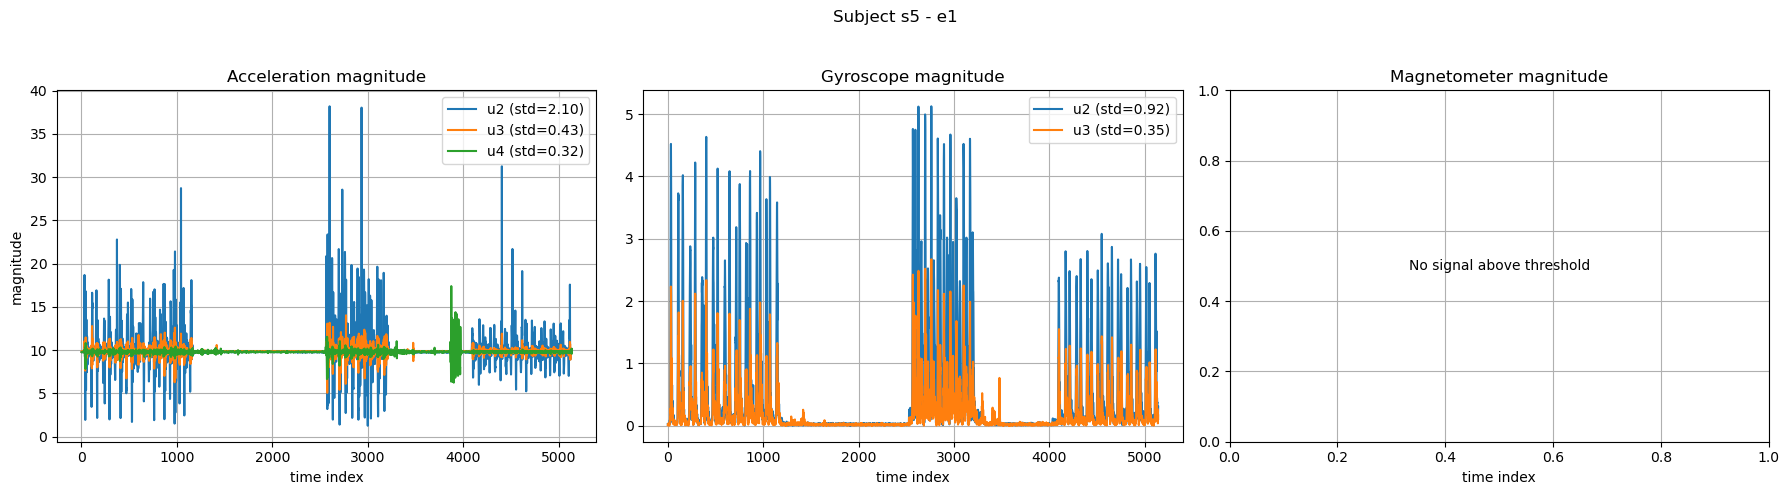


e2 — most active unit: u4
{'u1': 0.1547, 'u2': 0.1237, 'u3': 0.2514, 'u4': 1.052, 'u5': 0.2893}


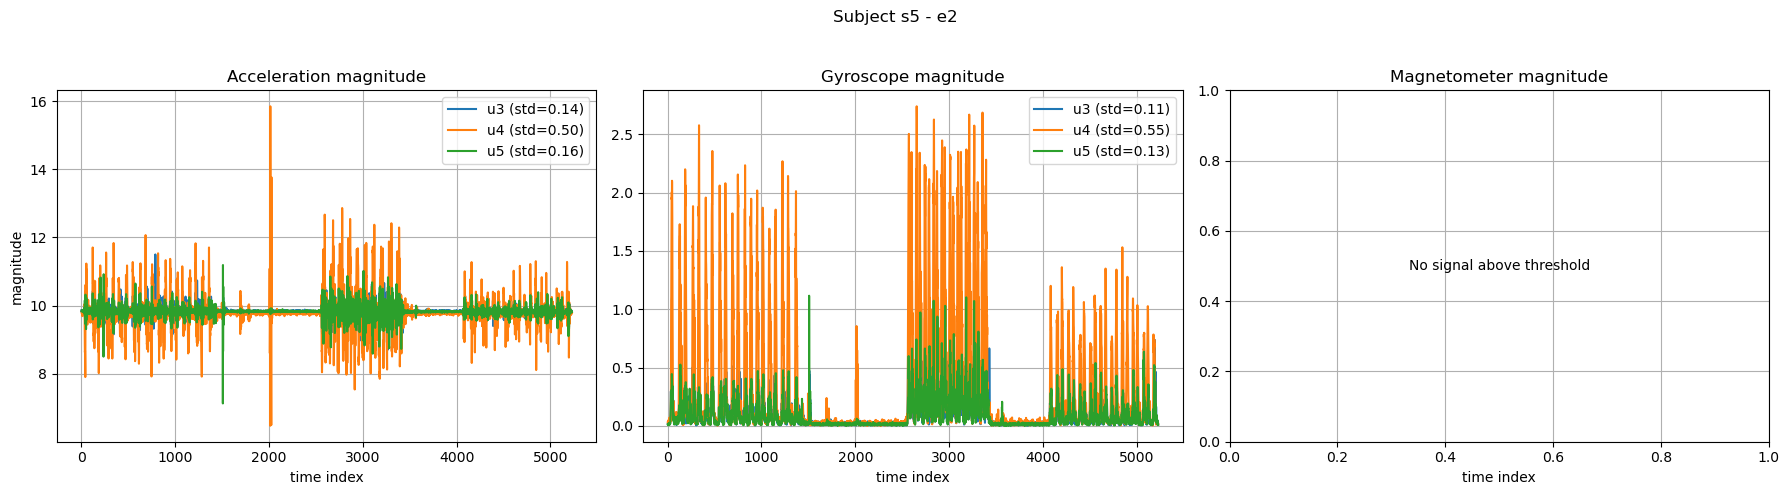


e3 — most active unit: u2
{'u1': 0.3792, 'u2': 4.7246, 'u3': 2.3469, 'u4': 0.2881, 'u5': 0.4663}


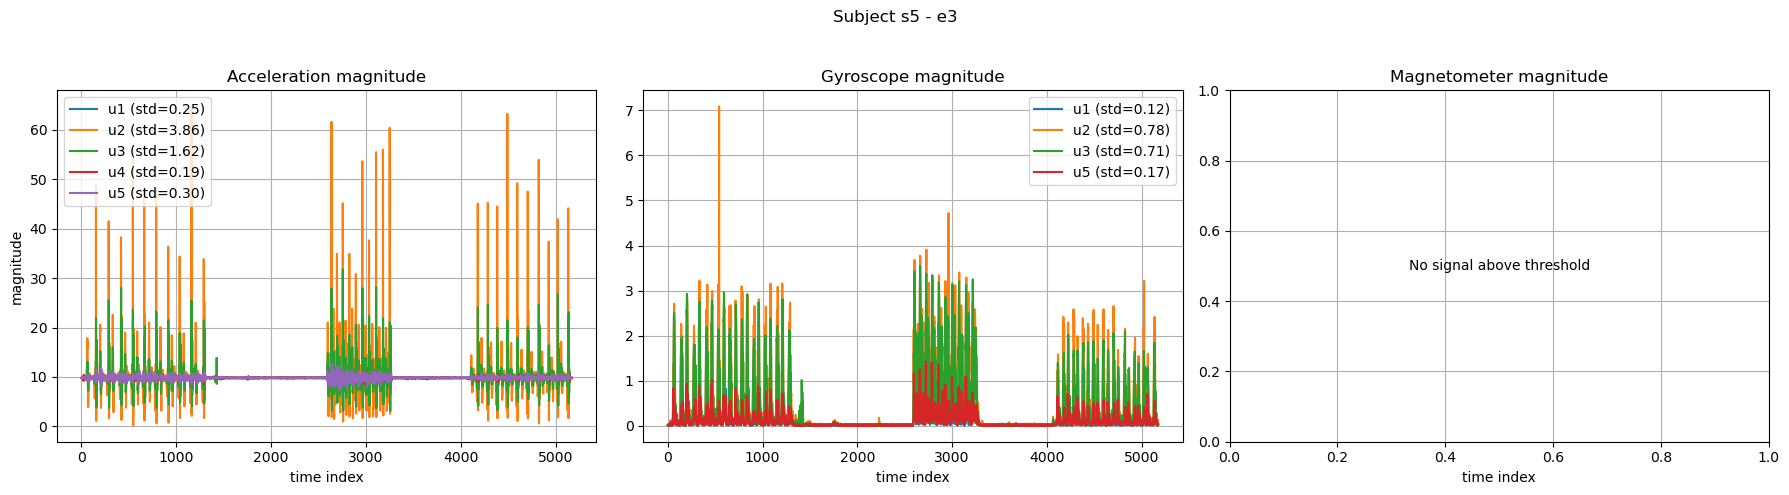


e4 — most active unit: u2
{'u1': 1.4423, 'u2': 4.8094, 'u3': 2.5638, 'u4': 0.2989, 'u5': 0.5942}


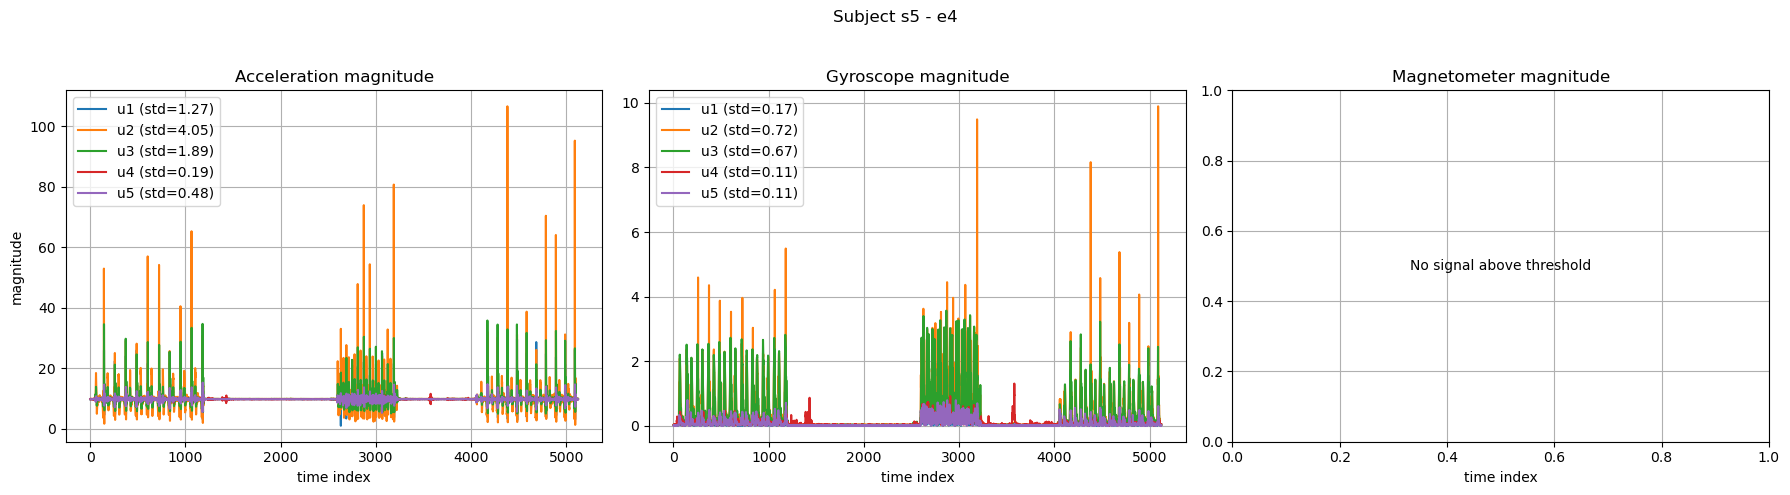


e5 — most active unit: u2
{'u1': 0.7673, 'u2': 4.7209, 'u3': 3.1254, 'u4': 0.2904, 'u5': 0.8182}


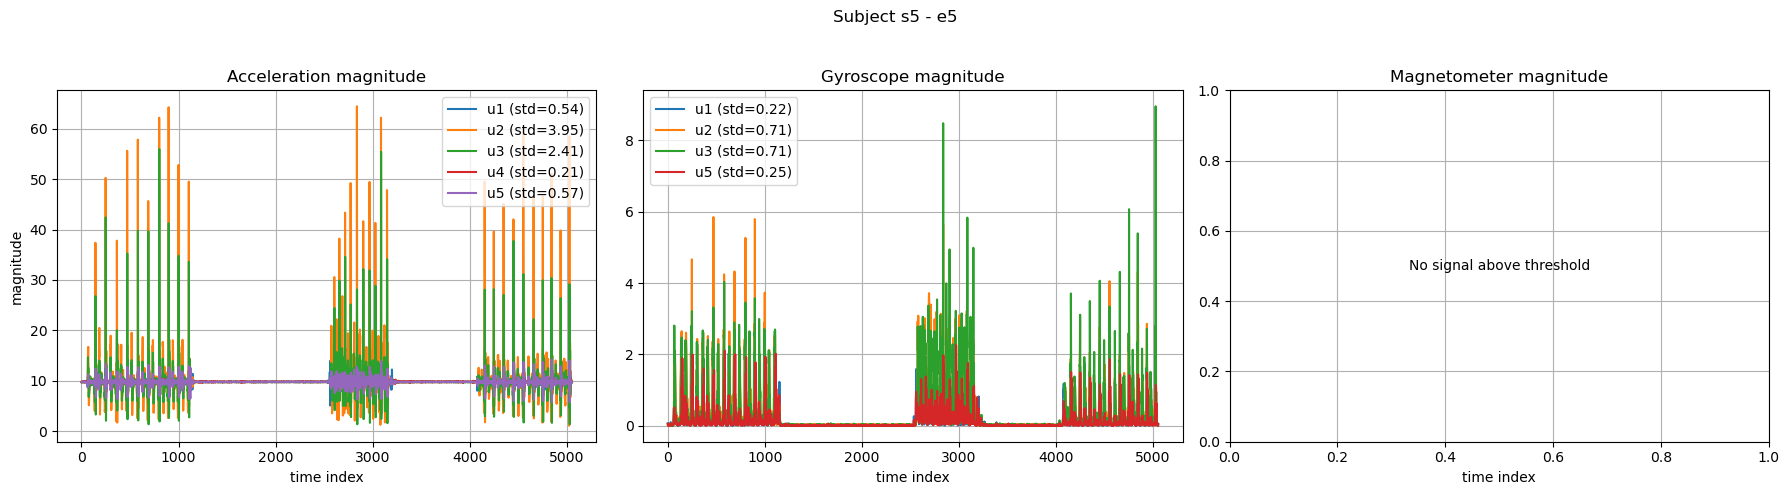


e6 — most active unit: u2
{'u1': 0.0544, 'u2': 4.0695, 'u3': 1.1316, 'u4': 0.3989, 'u5': 0.1504}


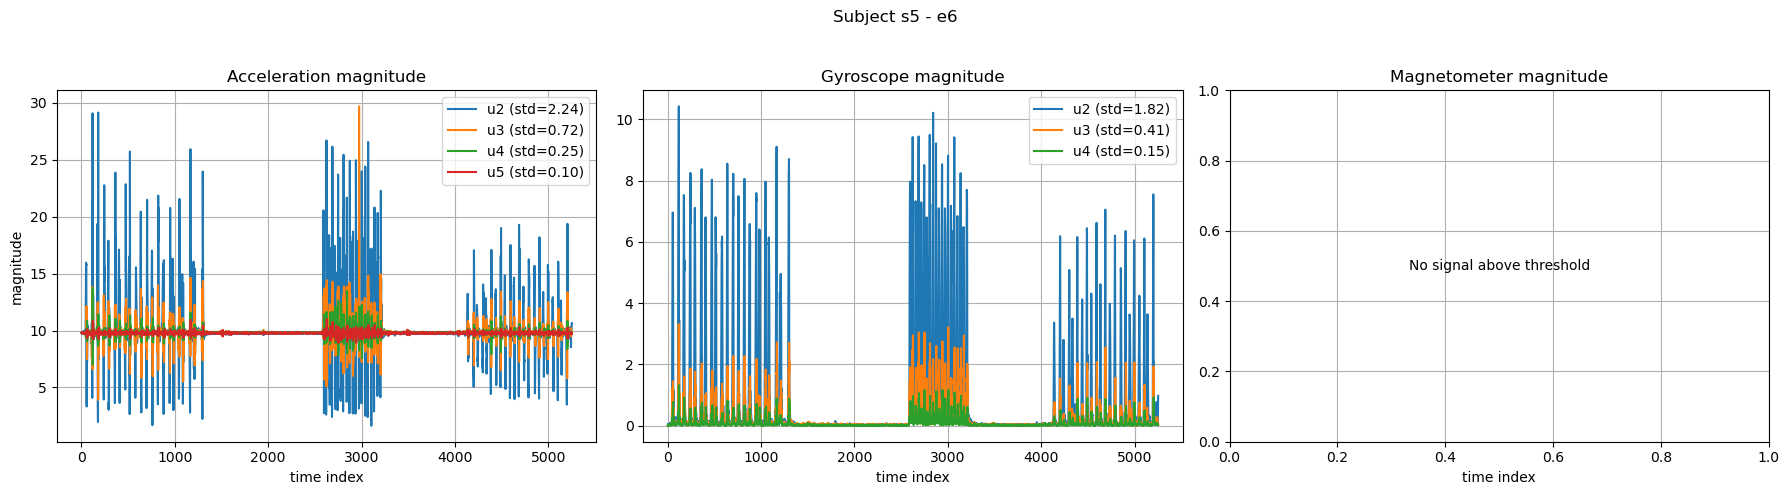


e7 — most active unit: u2
{'u1': 0.0756, 'u2': 3.5027, 'u3': 1.7606, 'u4': 0.5517, 'u5': 0.3252}


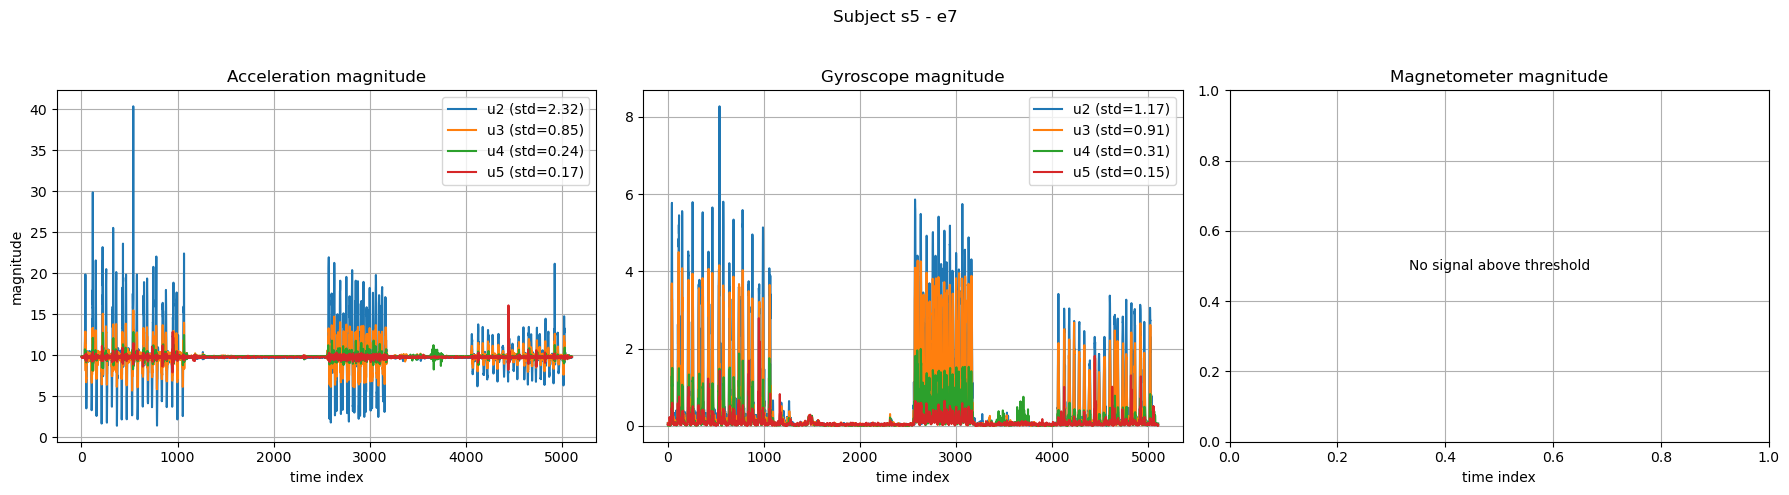


e8 — most active unit: u2
{'u1': 0.0632, 'u2': 2.9263, 'u3': 0.6202, 'u4': 0.3833, 'u5': 0.1046}


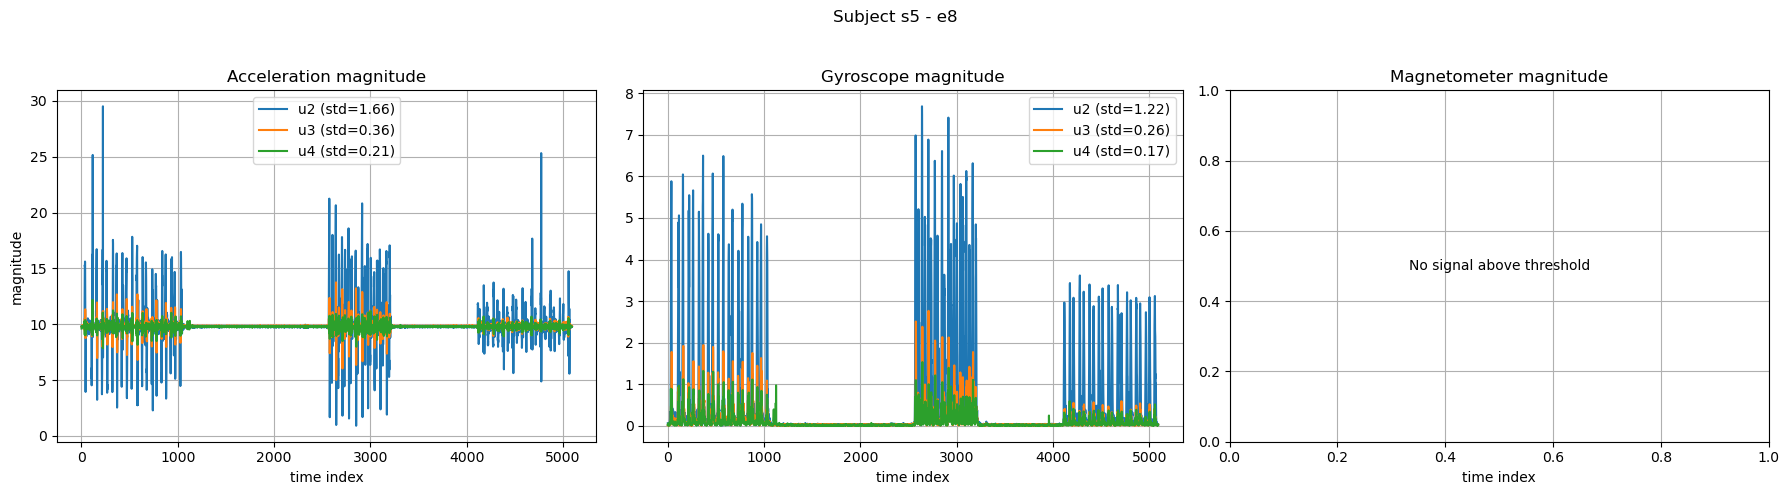

In [10]:
subject_ex=analyze_subject_exercises('s5', merged_df)

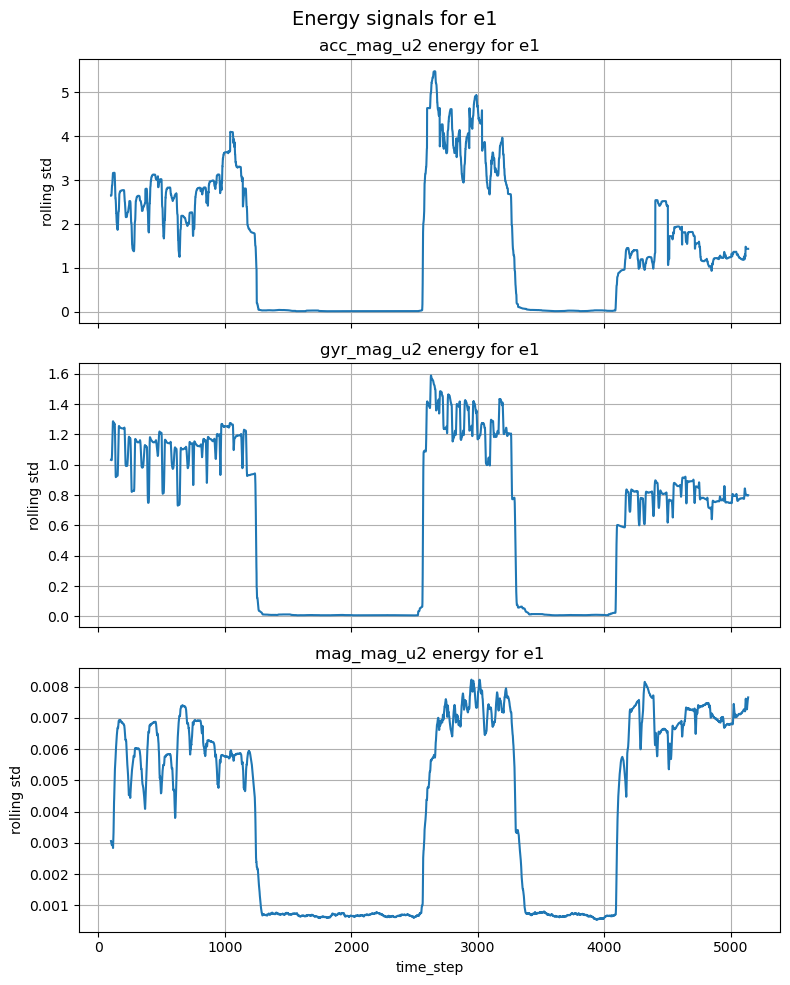

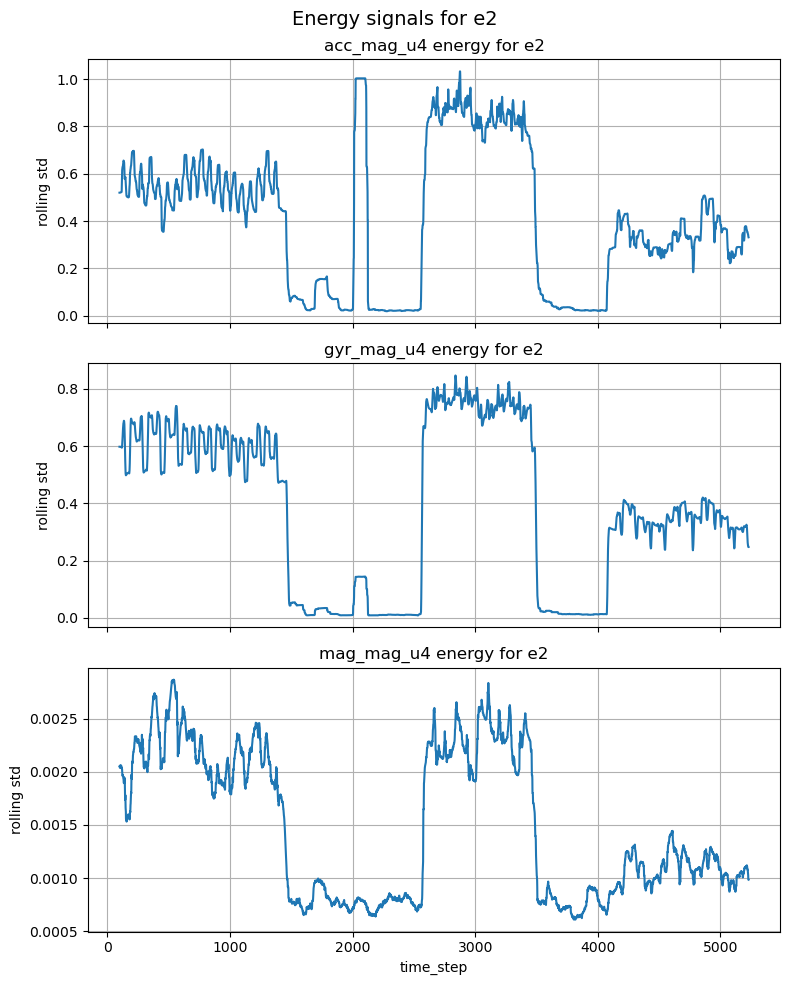

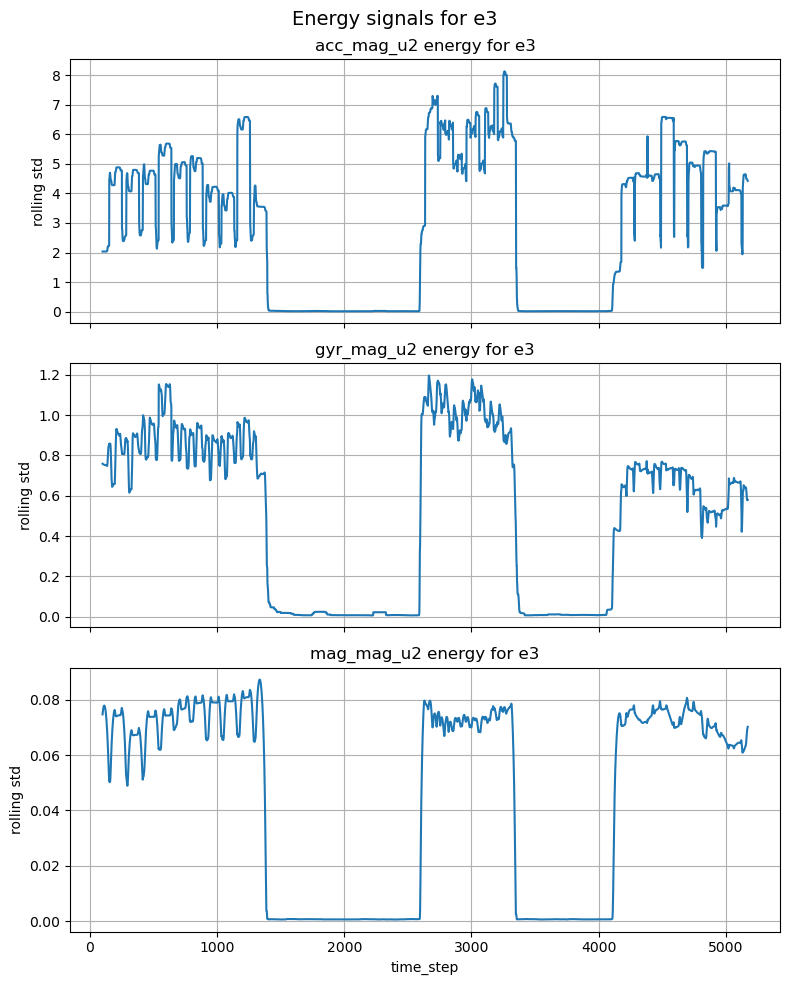

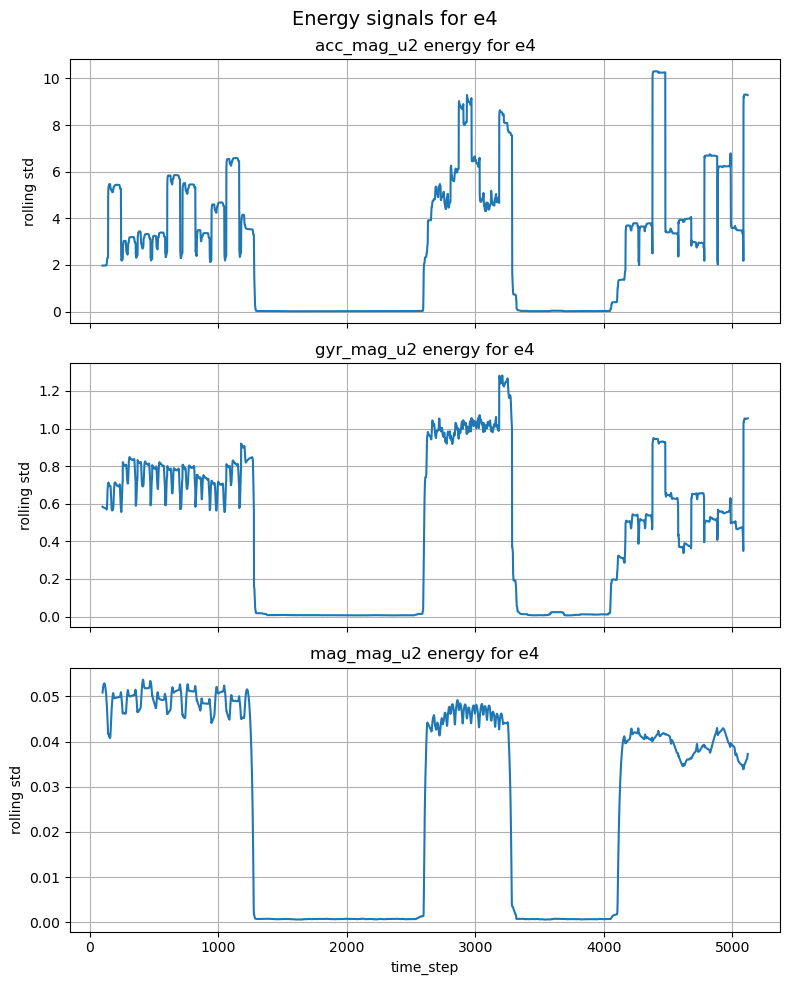

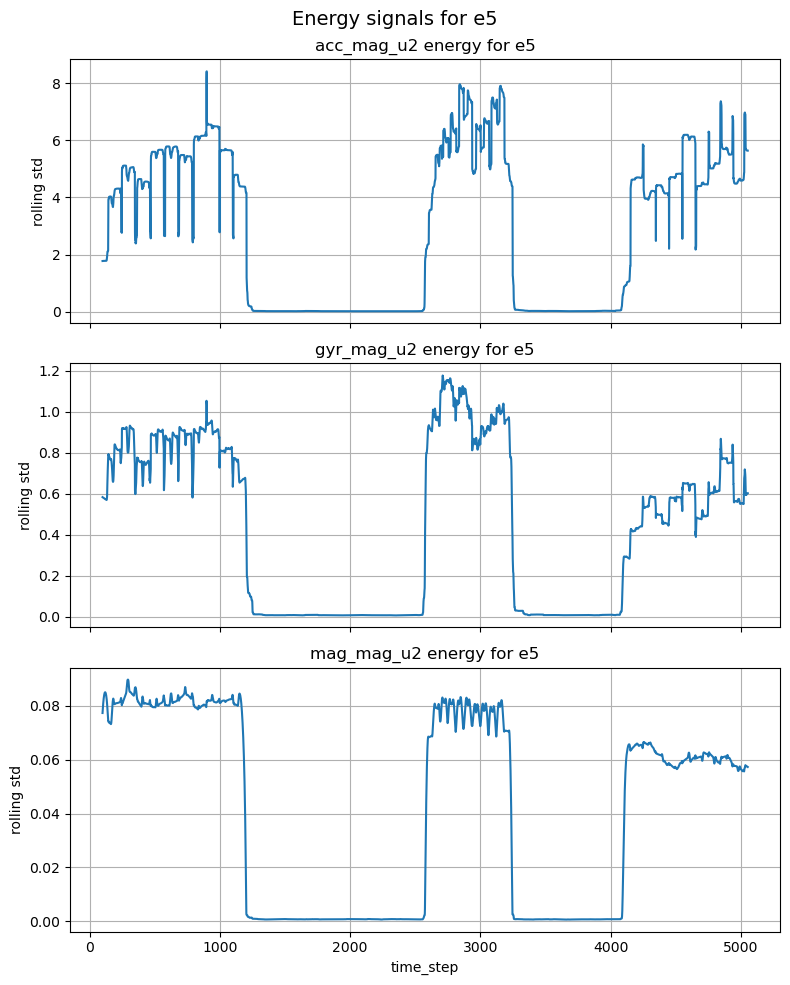

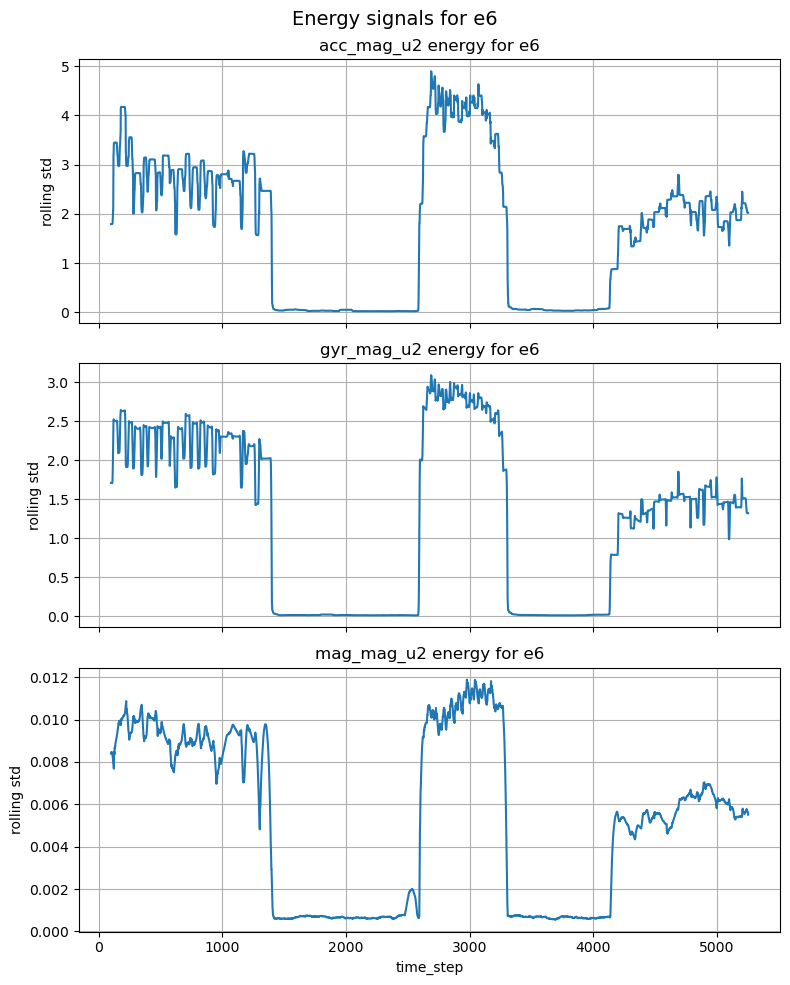

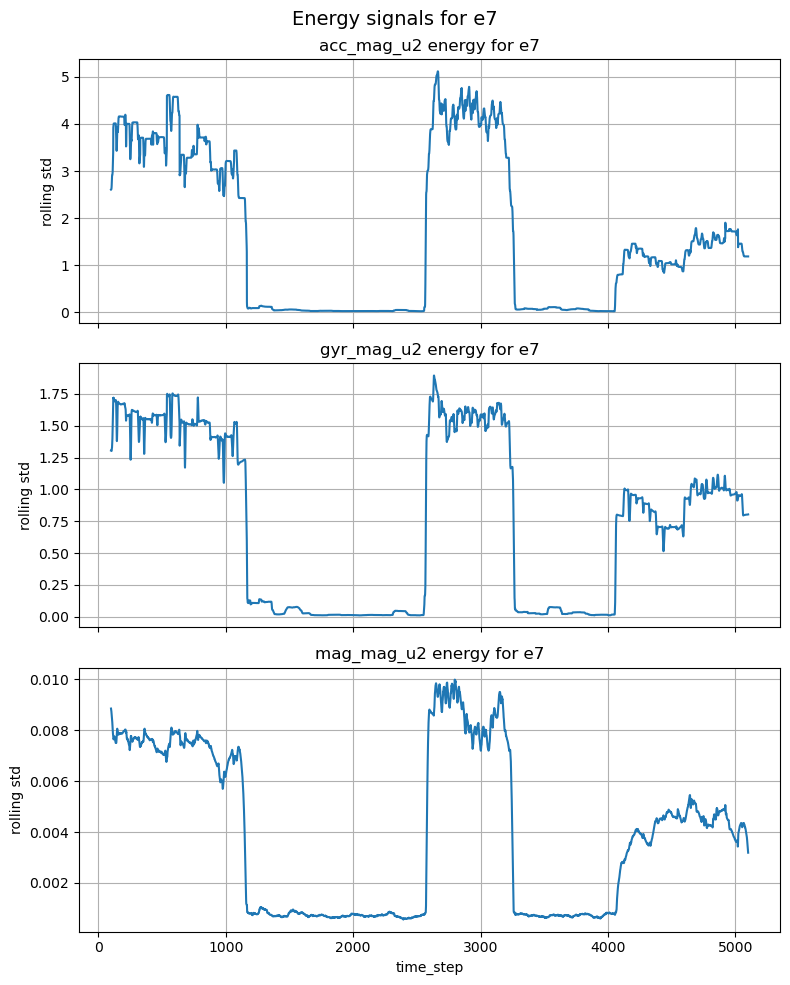

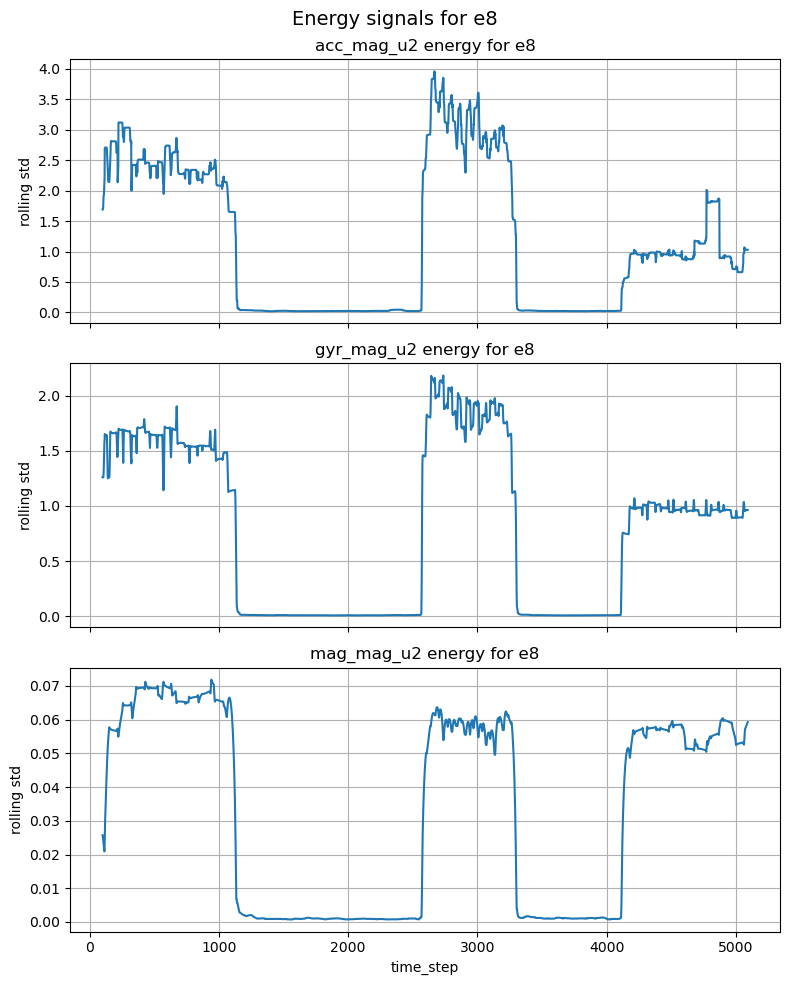

In [18]:
exercises = ['e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8']

for ex in exercises:
    sub = subject_ex[ex]

    unit = sub['most_active_unit'].iloc[0]
    columns = [f"acc_mag_{unit}", f"gyr_mag_{unit}", f"mag_mag_{unit}"]

    fig, axes = plt.subplots(3, 1, figsize=(8, 10), sharex=True)

    for i, column in enumerate(columns):
        signal = sub[column].to_numpy()
        energy = pd.Series(signal).rolling(100).std()

        axes[i].plot(energy)
        axes[i].set_ylabel('rolling std')
        axes[i].set_title(f"{column} energy for {ex}")
        axes[i].grid(True)

    axes[-1].set_xlabel('time_step')

    fig.suptitle(f"Energy signals for {ex}", fontsize=14)
    plt.tight_layout()
    plt.show()

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ex = 'e2'
sub = subject_ex[ex]

unit = sub['most_active_unit'].iloc[0]
columns = [f"acc_mag_{unit}", f"gyr_mag_{unit}", f"mag_mag_{unit}"]

# rolling std for each signal
energies = pd.DataFrame({
    col: sub[col].rolling(100, center=True).std()
    for col in columns
})

# one combined activity score
activity_score = energies.mean(axis=1)

<Axes: >

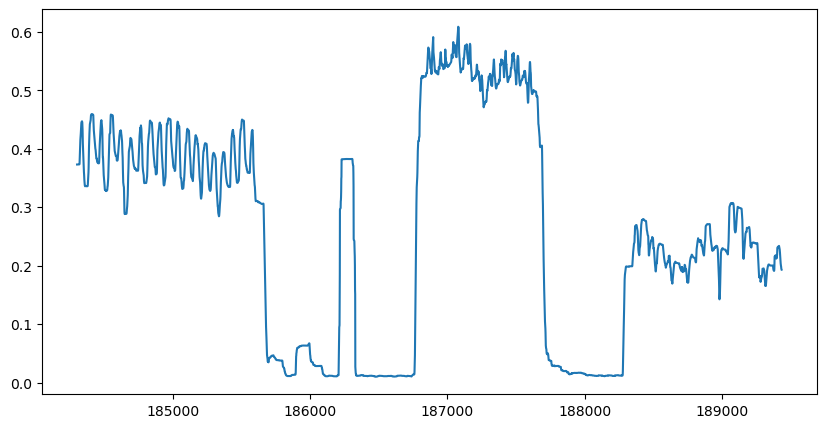

In [20]:
activity_score.plot(figsize=(10, 5))

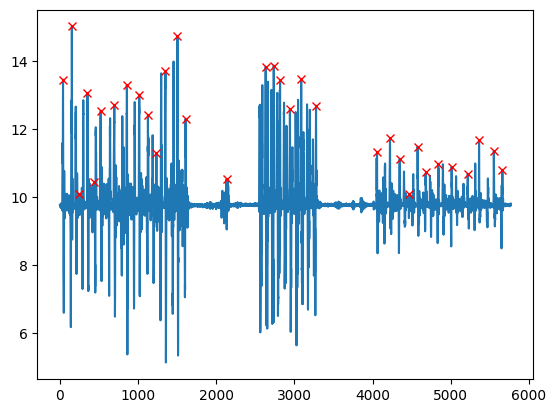

In [56]:
signal = subject_ex["acc_mag_u2"].to_numpy()
peaks, _ = find_peaks(signal, distance=80, prominence=0.6)

plt.plot(signal)
plt.plot(peaks, signal[peaks], "xr")
plt.show()



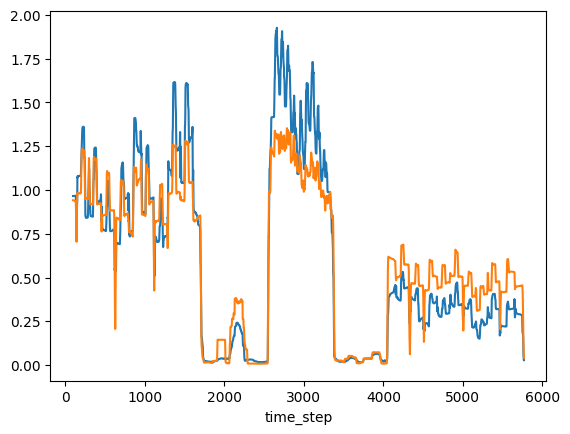

In [79]:
subject_ex['e1'].columns

Index(['subject', 'exercise', 'time index', 'acc_x_u1', 'acc_x_u2', 'acc_x_u3',
       'acc_x_u4', 'acc_x_u5', 'acc_y_u1', 'acc_y_u2', 'acc_y_u3', 'acc_y_u4',
       'acc_y_u5', 'acc_z_u1', 'acc_z_u2', 'acc_z_u3', 'acc_z_u4', 'acc_z_u5',
       'gyr_x_u1', 'gyr_x_u2', 'gyr_x_u3', 'gyr_x_u4', 'gyr_x_u5', 'gyr_y_u1',
       'gyr_y_u2', 'gyr_y_u3', 'gyr_y_u4', 'gyr_y_u5', 'gyr_z_u1', 'gyr_z_u2',
       'gyr_z_u3', 'gyr_z_u4', 'gyr_z_u5', 'mag_x_u1', 'mag_x_u2', 'mag_x_u3',
       'mag_x_u4', 'mag_x_u5', 'mag_y_u1', 'mag_y_u2', 'mag_y_u3', 'mag_y_u4',
       'mag_y_u5', 'mag_z_u1', 'mag_z_u2', 'mag_z_u3', 'mag_z_u4', 'mag_z_u5',
       'acc_mag_u1', 'gyr_mag_u1', 'mag_mag_u1', 'acc_mag_u2', 'gyr_mag_u2',
       'mag_mag_u2', 'acc_mag_u3', 'gyr_mag_u3', 'mag_mag_u3', 'acc_mag_u4',
       'gyr_mag_u4', 'mag_mag_u4', 'acc_mag_u5', 'gyr_mag_u5', 'mag_mag_u5',
       'most_active_unit'],
      dtype='str')

Most active unit: u4
Threshold: 0.3293
Idle periods found: [(np.int64(1412), np.int64(1962)), (np.int64(3447), np.int64(4096))]


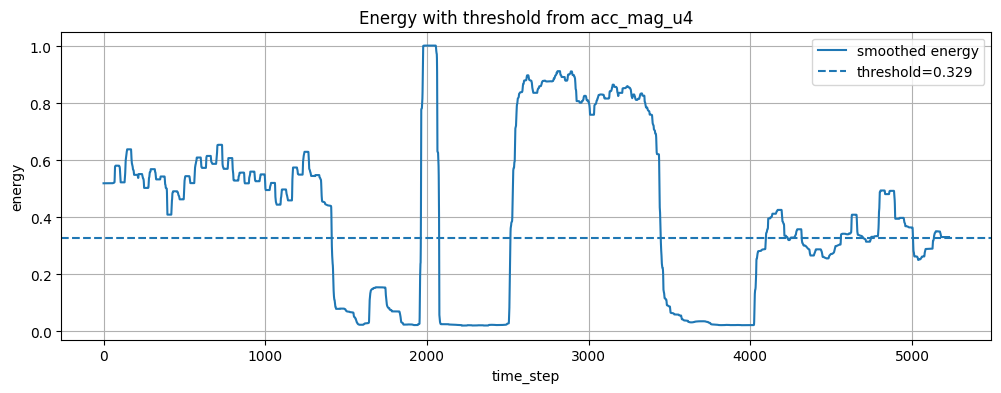

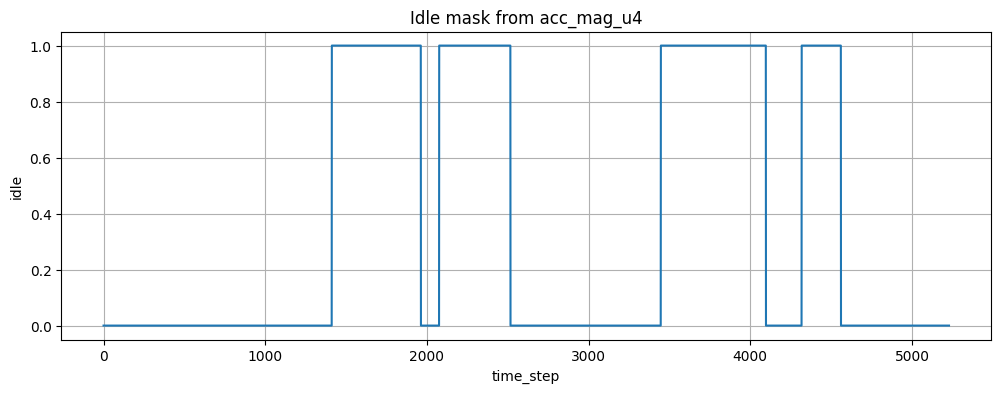

In [97]:
# Get the most active unit stored in the dataframe
sub1 = subject_ex["e2"]
unit = sub1['most_active_unit'].iloc[0]

# Build the corresponding acceleration magnitude column
column = f'acc_mag_{unit}'


signal = sub1[column].to_numpy()

# Rolling energy
energy = pd.Series(signal).rolling(100, center=True).std()
energy = energy.bfill().ffill()

# Optional smoothing of the energy itself
energy_smooth = energy.rolling(50, center=True).median().bfill().ffill()

# More permissive threshold
threshold = energy_smooth.quantile(0.40)

idle_mask = energy_smooth < threshold

# Remove very short idle fragments
min_idle_len = 150
groups = (idle_mask != idle_mask.shift()).cumsum()
for _, group in idle_mask.groupby(groups):
    if group.iloc[0] and len(group) < min_idle_len:
        idle_mask.loc[group.index] = False

# Recompute groups after cleaning
groups = (idle_mask != idle_mask.shift()).cumsum()
idle_groups = idle_mask[idle_mask].groupby(groups[idle_mask])
idle_periods = [(group.index[0], group.index[-1]) for _, group in idle_groups]

# Keep the 2 longest
idle_periods = sorted(idle_periods, key=lambda x: x[1] - x[0], reverse=True)[:2]
idle_periods = sorted(idle_periods, key=lambda x: x[0])

print(f"Most active unit: {unit}")
print(f"Threshold: {threshold:.4f}")
print("Idle periods found:", idle_periods)

# Diagnostic plots
plt.figure(figsize=(12,4))
plt.plot(energy_smooth, label='smoothed energy')
plt.axhline(threshold, linestyle='--', label=f'threshold={threshold:.3f}')
plt.xlabel('time_step')
plt.ylabel('energy')
plt.title(f'Energy with threshold from {column}')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12,4))
plt.plot(idle_mask.astype(int))
plt.xlabel('time_step')
plt.ylabel('idle')
plt.title(f'Idle mask from {column}')
plt.grid(True)
plt.show()

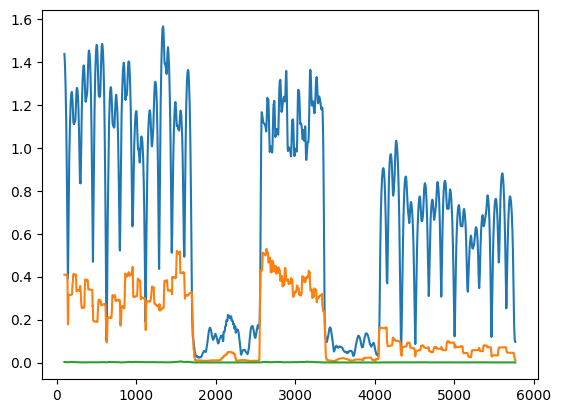

In [22]:
columns=["acc_mag_u3", 'gyr_mag_u3', 'mag_mag_u3']

for column in columns:
    signal = subject_ex[column].to_numpy()
    energy = pd.Series(signal).rolling(100).std()

    plt.plot(energy)

    

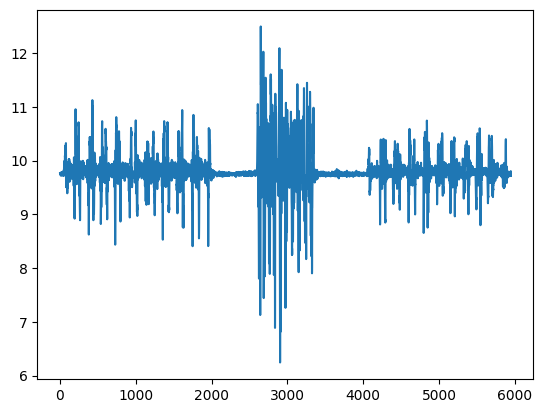

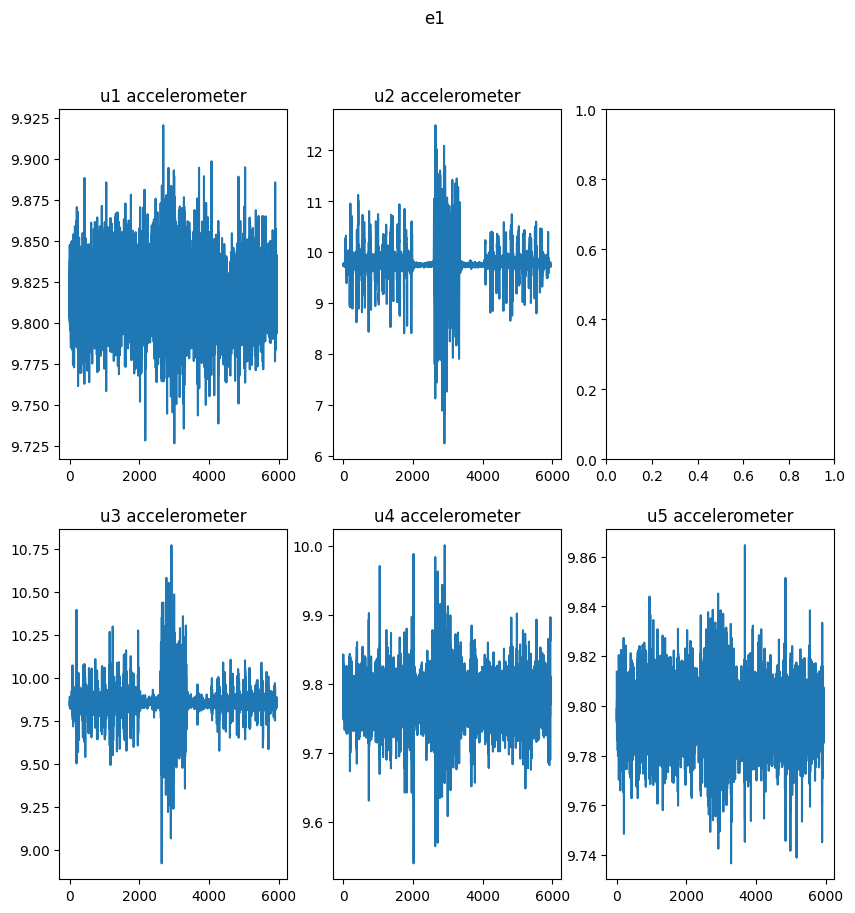

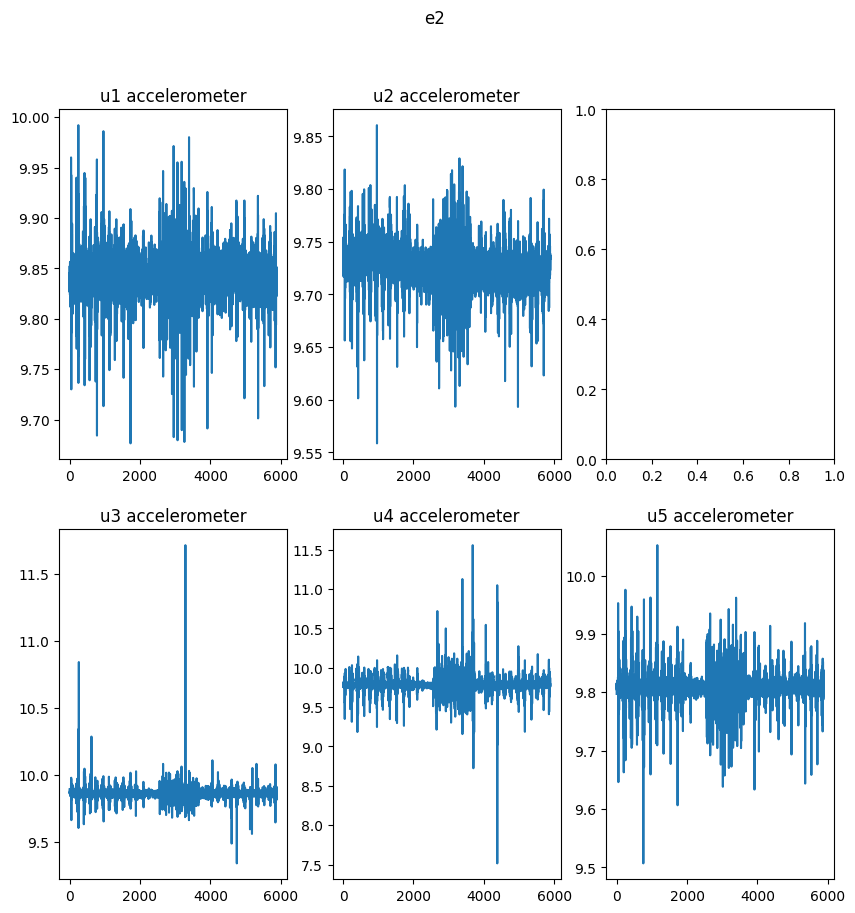

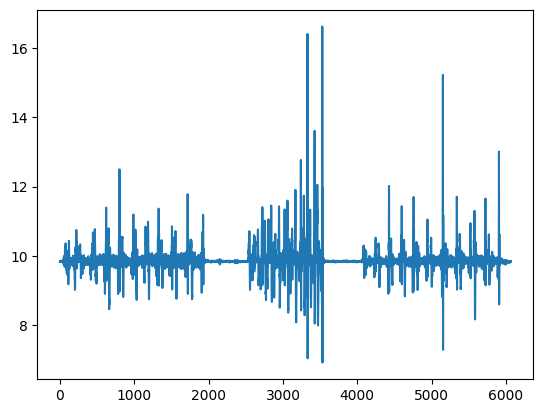

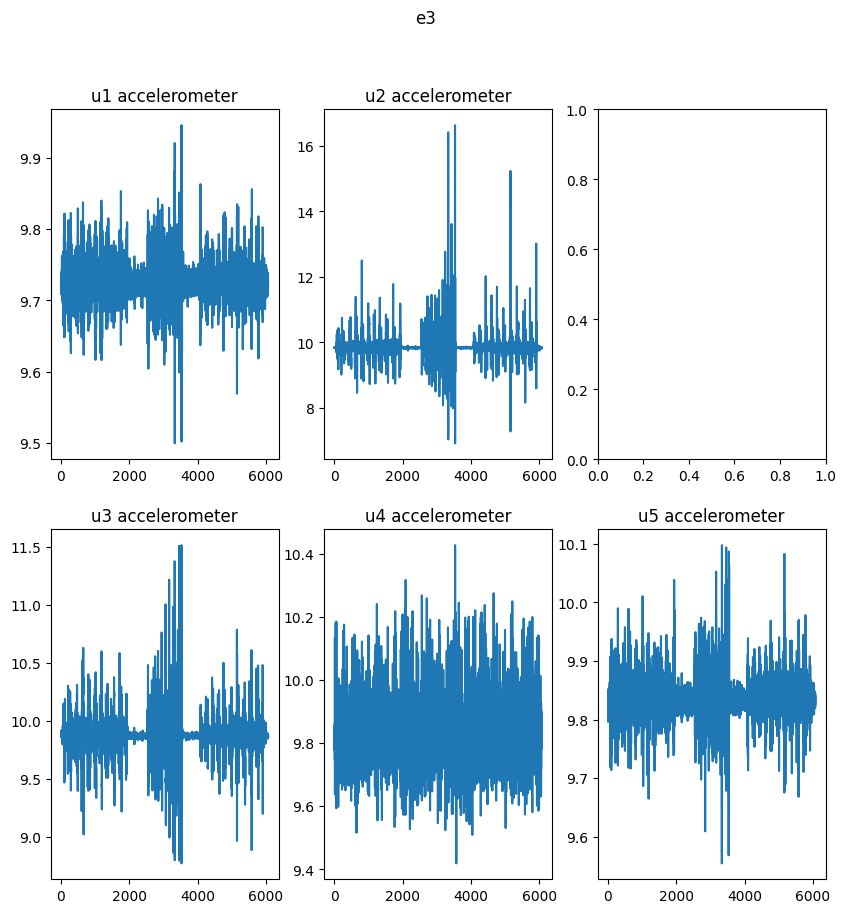

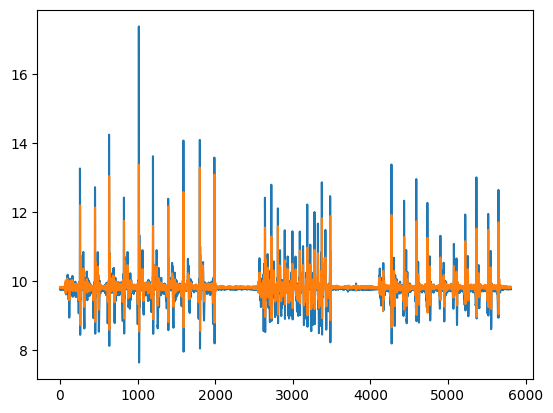

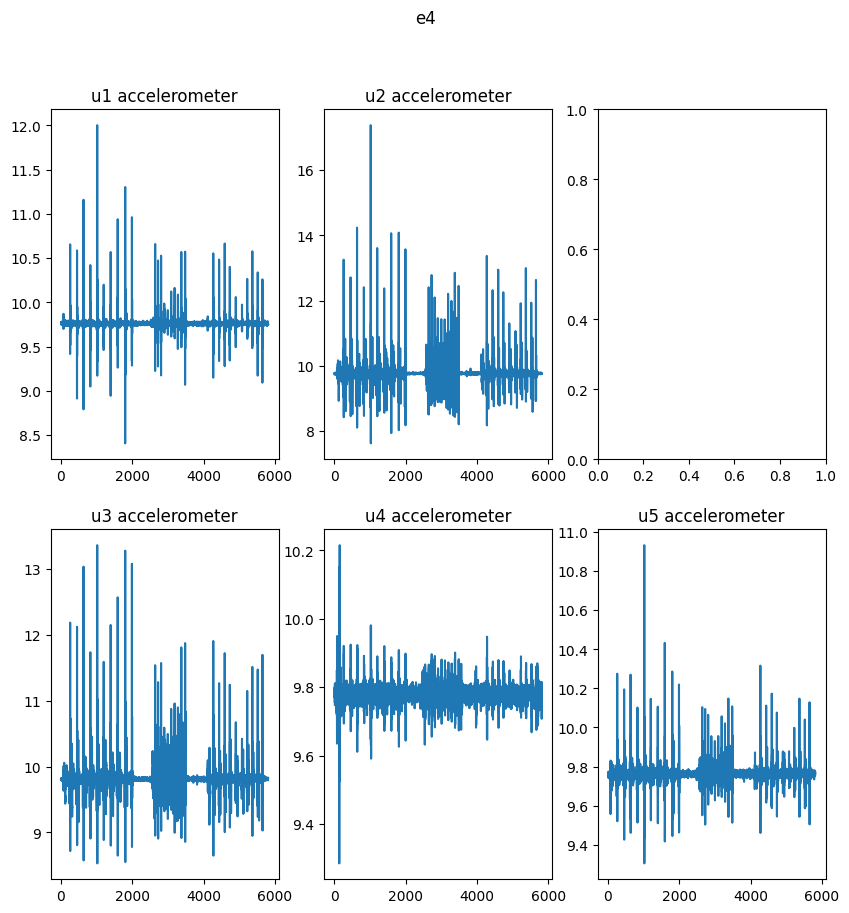

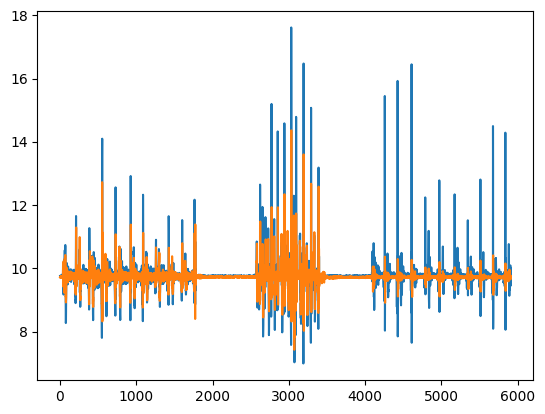

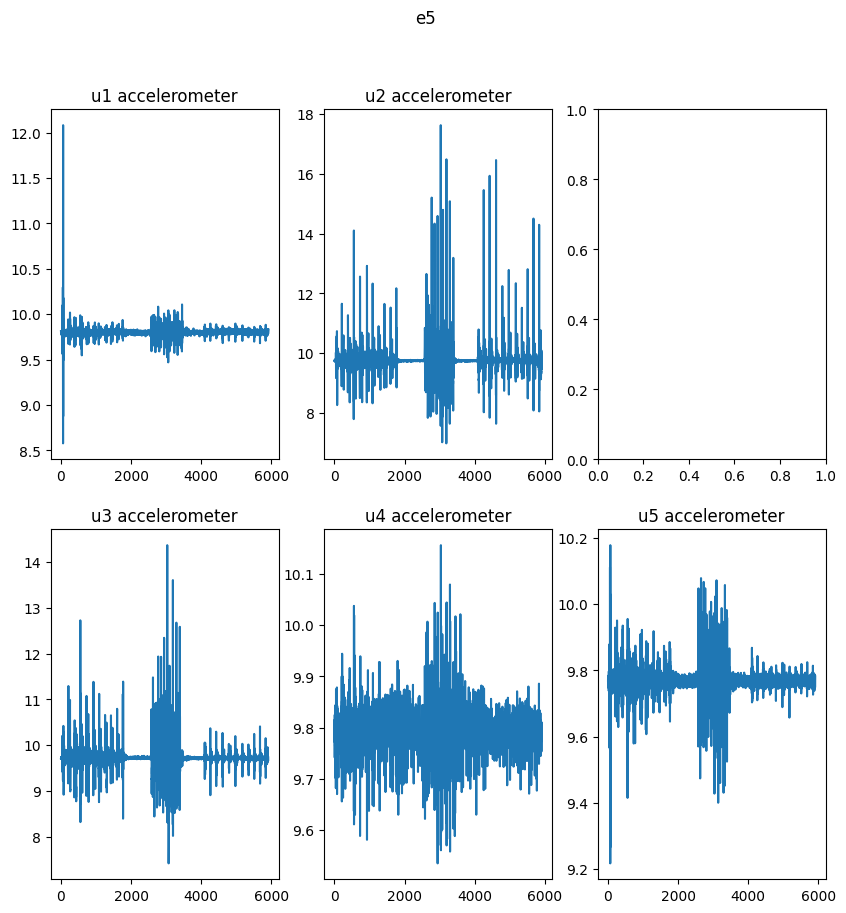

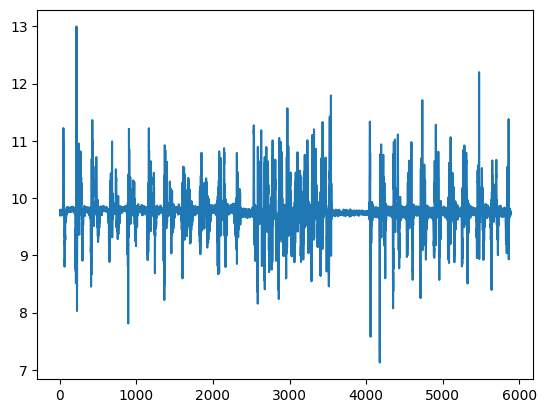

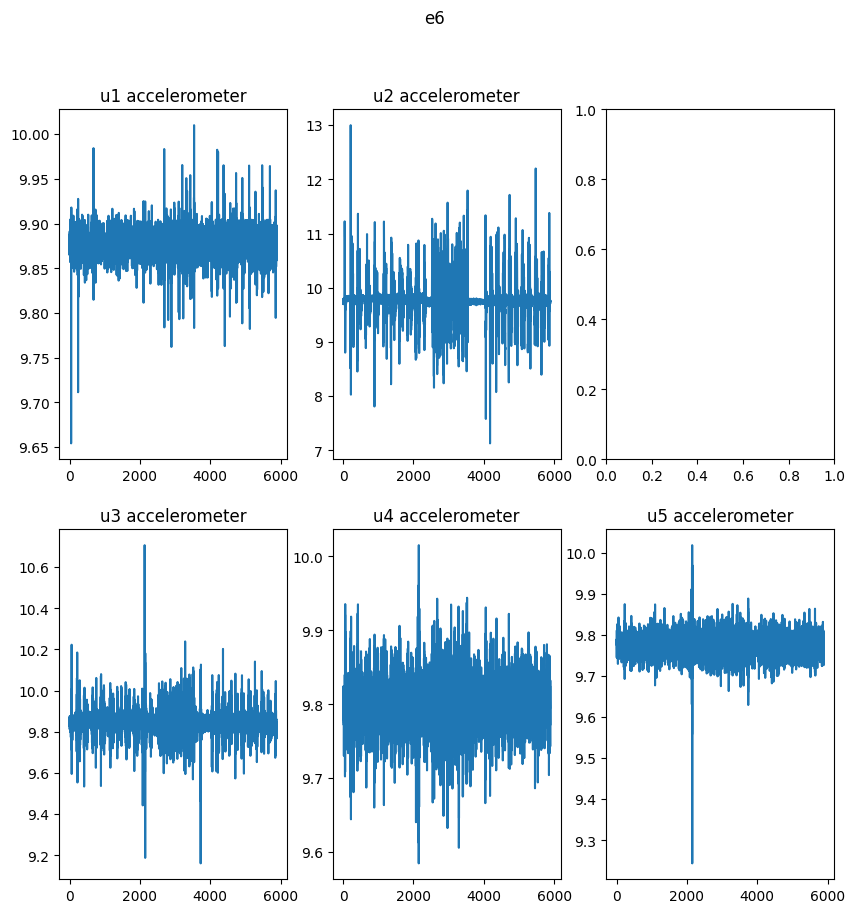

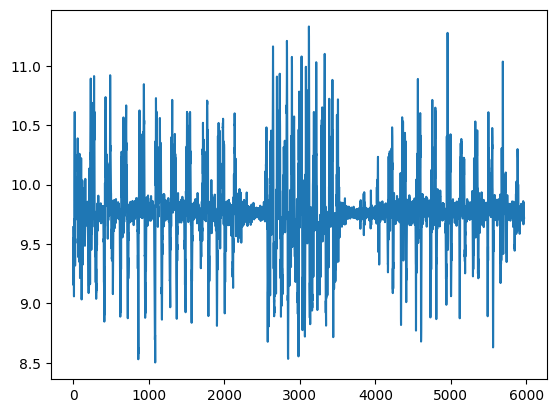

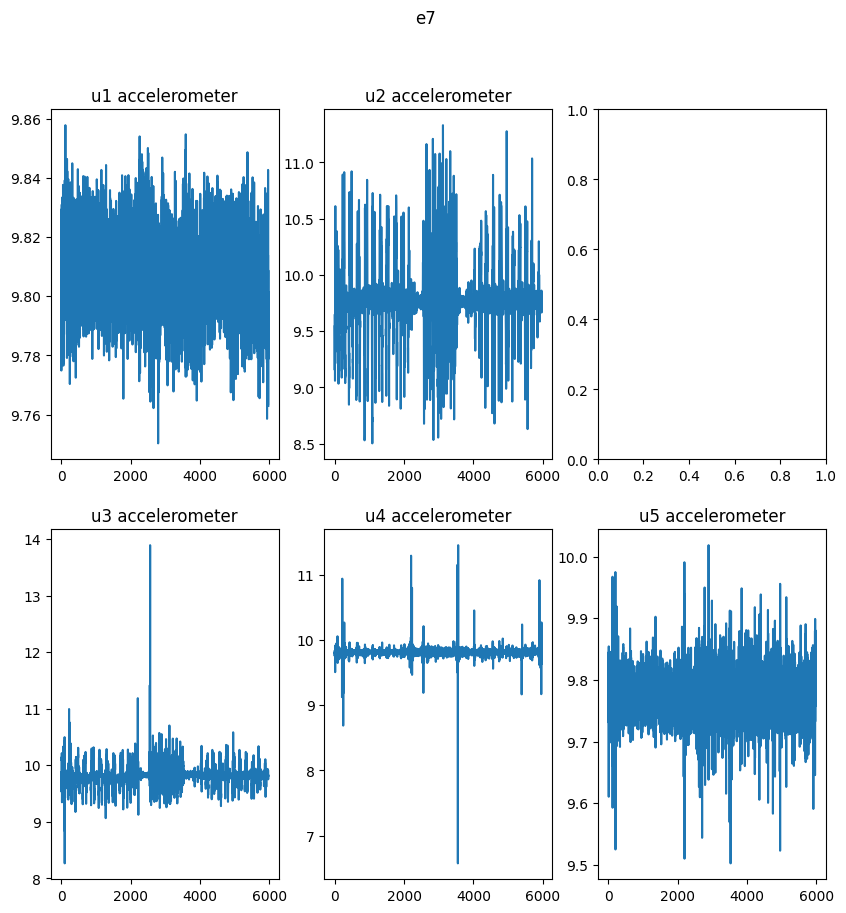

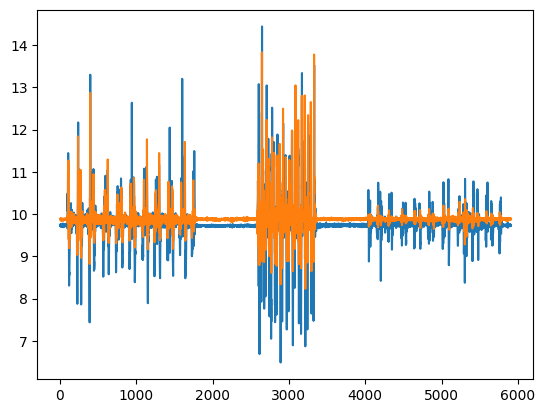

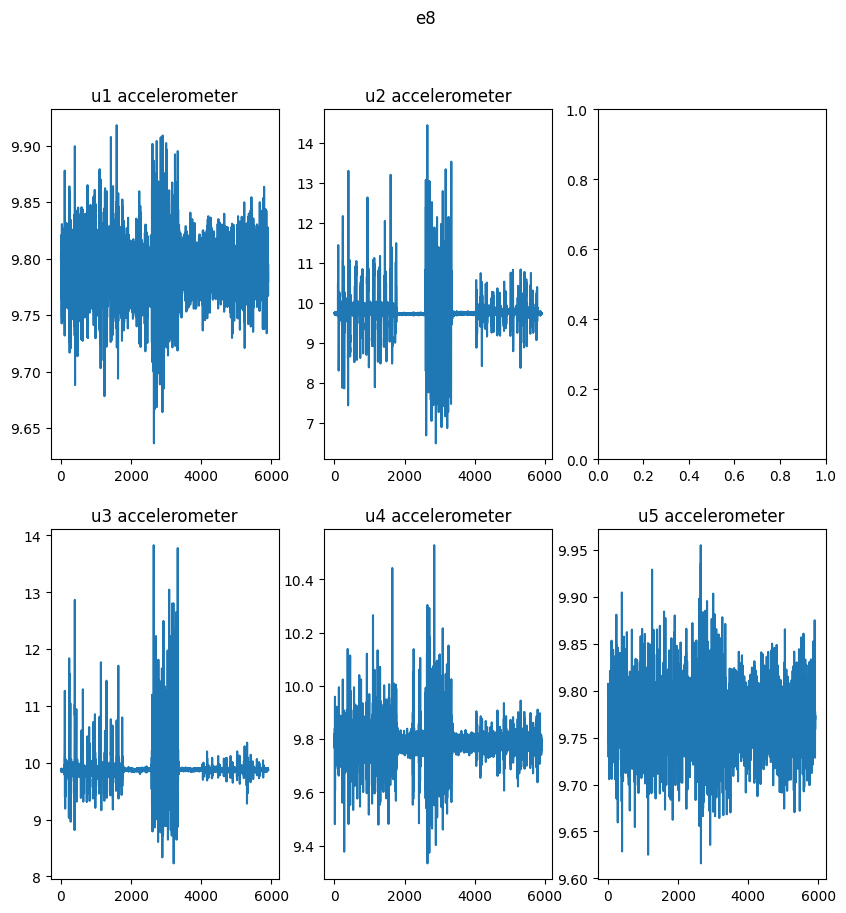

In [23]:

subject=merged_df[merged_df['subject']=='s1']

exercises = ['e1', 'e2', 'e3', 'e4', 'e5', 'e6', 'e7', 'e8']

for exercise in exercises:
    subject_ex = subject[subject['exercise'] == exercise].copy()
    
    subject_ex["acc_mag_u1"] = np.sqrt(      
        subject_ex["acc_x_u1"]**2 +
        subject_ex["acc_y_u1"]**2 +
        subject_ex["acc_z_u1"]**2
    )

    subject_ex["acc_mag_u2"] = np.sqrt(      
        subject_ex["acc_x_u2"]**2 +
        subject_ex["acc_y_u2"]**2 +
        subject_ex["acc_z_u2"]**2
    )

    subject_ex["acc_mag_u3"] = np.sqrt(      
        subject_ex["acc_x_u3"]**2 +
        subject_ex["acc_y_u3"]**2 +
        subject_ex["acc_z_u3"]**2
    )

    subject_ex["acc_mag_u4"] = np.sqrt(      
        subject_ex["acc_x_u4"]**2 +
        subject_ex["acc_y_u4"]**2 +
        subject_ex["acc_z_u4"]**2
    )

    subject_ex["acc_mag_u5"] = np.sqrt(      
        subject_ex["acc_x_u5"]**2 +
        subject_ex["acc_y_u5"]**2 +
        subject_ex["acc_z_u5"]**2
    )

    threshold = 0.2   # example threshold

    for u in range(1,6):

        std = subject_ex[f"acc_mag_u{u}"].std()

        if std > threshold:
            plt.plot(subject_ex["time index"], subject_ex[f"acc_mag_u{u}"],
                    label=f"u{u} (std={std:.2f})")



    fig, axes= plt.subplots(ncols=3, nrows=2, figsize=(10,10))
    fig.suptitle(exercise)
    axes[0,0].plot(subject_ex["time index"], subject_ex["acc_mag_u1"])
    axes[0,0].set_title('u1 accelerometer')

    axes[0,1].plot(subject_ex["time index"], subject_ex["acc_mag_u2"])
    axes[0,1].set_title('u2 accelerometer')

    axes[1,0].plot(subject_ex["time index"], subject_ex["acc_mag_u3"])
    axes[1,0].set_title('u3 accelerometer')


    axes[1,1].plot(subject_ex["time index"],subject_ex["acc_mag_u4"])
    axes[1,1].set_title('u4 accelerometer')


    axes[1,2].plot(subject_ex["time index"], subject_ex["acc_mag_u5"])
    axes[1,2].set_title('u5 accelerometer')

    plt.show()